# EEG Trigger Press · LightGBM — Multi-Trial LOTO CV

Predicts whether the subject will **press the trigger** at the next sample  
from a causal window of T EEG samples across all channels.

### Design choices

| | Choice | Reason |
|---|---|---|
| Model | **LightGBM** | Faster than RF, strong on tabular data |
| Band-pass | **0.1 – 60 Hz** | Preserves MRCP slow pre-movement drift |
| Window T | **Optuna, 64 ms – 1 s** | Motor prep spans up to 1 s before press |
| CV | **LOTO** (Leave-One-Trial-Out) | Full trials held out — no adjacent-window leakage |
| Optuna metric | **Average Precision (PR-AUC)** | Emphasises recall of minority class (pressed) |
| Threshold | **Max sensitivity s.t. specificity ≥ 0.8** | Catches most presses while limiting false alarms |

## 1 · Imports & Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")
import json
import os
import sys

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

sys.path.insert(0, "..")
from src.preprocessing import build_windows, load_trial, make_horizon_labels

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
LIME = "#a8ff3e"
WHITE = "#f0f4ff"

print("All imports OK.")

All imports OK.


## 2 · Config

In [2]:
SUBJECT = 9
TACHE = "spt"
ALL_TRIALS = list(range(10))
DATA_PATH = f"../data/subject{SUBJECT}/"
FS     = 250
DECIM  = 4        # downsampling factor (1 = off)
STRIDE = 1        # window stride in samples at FS_EFF
FS_EFF = FS // DECIM
LP, HP = 0.5, 8.0  # narrowband: MRCP lives in delta/slow-cortical (0.5–8 Hz)
HORIZON = int(1.0 * FS_EFF)  # anticipatory label lookahead: 1000 ms (full Bereitschaftspotential)
TARGET = "button"

N_TRIALS_OPTUNA = 30
SMOOTH_WINDOW_S = 0.5                      # smoothing look-back in seconds
SMOOTH_WINDOW   = int(SMOOTH_WINDOW_S * FS_EFF)  # samples at FS_EFF
MIN_SPECIFICITY = 0.80

# ── Speed knobs ───────────────────────────────────────────────────────────
T_MAX_S = 1.0                    # max look-back in seconds
T_MAX   = int(T_MAX_S * FS_EFF)  # samples at FS_EFF — Optuna slices from here
N_ESTIMATORS = 500
EARLY_STOP = 30
OPTUNA_FOLDS = ALL_TRIALS[::2]   # 5 folds during search (every other trial)

print(f"FS / FS_EFF    : {FS} Hz → {FS_EFF} Hz  (DECIM={DECIM})")
print(f"LP / HP        : {LP} – {HP} Hz  (MRCP narrowband)")
print(f"HORIZON        : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms lookahead)")
print(f"T_MAX          : {T_MAX} samples  ({T_MAX/FS_EFF*1000:.0f} ms)")
print(f"SMOOTH_WINDOW  : {SMOOTH_WINDOW} samples  ({SMOOTH_WINDOW/FS_EFF*1000:.0f} ms)")

FS / FS_EFF    : 250 Hz → 62 Hz  (DECIM=4)
LP / HP        : 0.5 – 8.0 Hz  (MRCP narrowband)
HORIZON        : 62 samples  (1000 ms lookahead)
T_MAX          : 62 samples  (1000 ms)
SMOOTH_WINDOW  : 31 samples  (500 ms)


## 3 · Load & Filter All Trials

In [3]:
print("Loading and filtering all trials …")
raw_data = {}
EEG_COLS = None

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT, TACHE, t, DATA_PATH, eeg_cols=EEG_COLS, lp=LP, hp=HP, decimate=DECIM,
        car=True
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    raw_data[t] = (X_t, y_t)
    n_press = int(y_t.sum())
    print(
        f"  trial {t:2d}: {len(df):6,} samples  "
        f"horizon-press={n_press:5,} ({n_press/len(df)*100:.1f}%)  "
        f"no-press={int((y_t==0).sum()):6,}"
    )

N_CHANNELS = len(EEG_COLS)
print(f"\nChannels ({N_CHANNELS}): {EEG_COLS}")

Loading and filtering all trials …
Setting up band-pass filter from 0.5 - 8 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


- Windowed time-domain design (firwin) method


...

- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


- Upper passband edge: 8.00 Hz


- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)


- Filter length: 1651 samples (6.604 s)


  trial  9:  4,298 samples  horizon-press=2,558 (59.5%)  no-press= 1,740

Channels (16): ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


## 4 · Build Windows Helper

In [4]:
def smooth_probs(probs, window=SMOOTH_WINDOW):
    """Causal rolling-mean smoother — collapses sub-second false-positive spikes."""
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def best_threshold(fpr, tpr, thresholds, min_spec=MIN_SPECIFICITY):
    """Max sensitivity s.t. specificity >= min_spec. Falls back to Youden's J."""
    valid = (1 - fpr) >= min_spec
    if valid.any():
        return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])  # Youden's J fallback


# ── Pre-compute windows at T_MAX once ────────────────────────────────────
print(f"Pre-computing windows at T_MAX={T_MAX} …")
_X_raw, _y_raw, _tid_raw = [], [], []
for _t in ALL_TRIALS:
    X_t, y_t = raw_data[_t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False, stride=STRIDE)
    _X_raw.append(Xw.reshape(-1, T_MAX, N_CHANNELS))
    _y_raw.append(yw)
    _tid_raw.append(np.full(len(yw), _t, dtype=np.int32))

_X_max = np.concatenate(_X_raw)  # (M, T_MAX, C)
_y_max = np.concatenate(_y_raw)
_tid_max = np.concatenate(_tid_raw)
del _X_raw, _y_raw, _tid_raw
n_press = int(_y_max.sum())
print(f"  shape={_X_max.shape}  memory={_X_max.nbytes/1e9:.2f} GB")
print(f"  windows={len(_y_max):,}  press={n_press:,} ({n_press/len(_y_max)*100:.1f}%)")


def get_windows_for_T(T: int):
    """Slice pre-computed T_MAX array to T lags + vectorised per-window normalisation."""
    X = _X_max[:, T_MAX - T :, :].copy()  # (M, T, C)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).reshape(len(_y_max), T * N_CHANNELS), _y_max, _tid_max


Pre-computing windows at T_MAX=62 …


  shape=(41724, 62, 16)  memory=0.17 GB
  windows=41,724  press=22,828 (54.7%)


## 5 · Optuna Search

**Objective:** mean LOTO **Average Precision** (PR-AUC) — threshold-independent and  
naturally weighted toward recall of the minority class (pressed).

**Speed optimisations applied:**
- Windows pre-computed at T_MAX; each trial just slices — no rebuild
- `n_estimators` fixed at 500 with **early stopping** (patience=30) using a 10% train holdout
- **5 LOTO folds** during search (every other trial); full 10-fold run in §7

In [5]:
def objective(trial):
    T = trial.suggest_int("T", max(4, FS_EFF // 16), T_MAX, log=True)
    num_leaves = trial.suggest_int("num_leaves", 15, 255, log=True)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

    X_p, y_p, tid_p = get_windows_for_T(T)  # fast slice — no rebuild

    clf = lgb.LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        class_weight=class_weight,
        max_depth=-1,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    fold_aps = []
    for fold, test_trial in enumerate(OPTUNA_FOLDS):
        te_mask = tid_p == test_trial
        X_te, y_te = X_p[te_mask], y_p[te_mask]
        X_tr_full, y_tr_full = X_p[~te_mask], y_p[~te_mask]

        n_val = max(1, int(0.1 * len(y_tr_full)))
        X_tr, y_tr = X_tr_full[n_val:], y_tr_full[n_val:]
        X_val, y_val = X_tr_full[:n_val], y_tr_full[:n_val]

        clf.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(EARLY_STOP, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        probs = clf.predict_proba(X_te)[:, 1]
        ap = average_precision_score(y_te, probs)
        fold_aps.append(ap)

        trial.report(np.mean(fold_aps), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aps))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f"\nBest trial : #{study.best_trial.number}")
print(f"Best AP    : {study.best_value:.4f}")
print("\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:24s}: {v}")


  0%|          | 0/30 [00:00<?, ?it/s]


Best trial : #18
Best AP    : 0.6454

Best params:
  T                       : 61
  num_leaves              : 22
  learning_rate           : 0.07285015665601155
  min_child_samples       : 5
  subsample               : 0.8594241380363734
  colsample_bytree        : 0.889007663148546
  class_weight            : None


## 6 · Extract Best Config & Rebuild Dataset

In [6]:
p = study.best_params

T = p["T"]
num_leaves = p["num_leaves"]
learning_rate = p["learning_rate"]
min_child_samples = p["min_child_samples"]
subsample = p["subsample"]
colsample_bytree = p["colsample_bytree"]
class_weight = p["class_weight"]

X_pool, y_pool, tid_pool = get_windows_for_T(T)

print(f"Best T        : {T} samples  ({T/FS_EFF*1000:.0f} ms look-back)")
print(f"Feature size  : {N_CHANNELS} × {T} = {N_CHANNELS*T} per window")
print(
    f"Total windows : {len(y_pool):,}  (press={y_pool.sum():,}  no-press={(y_pool==0).sum():,})"
)
print(f"num_leaves    : {num_leaves}")
print(f"learning_rate : {learning_rate:.4f}")
print(f"class_weight  : {class_weight}")


Best T        : 61 samples  (984 ms look-back)
Feature size  : 16 × 61 = 976 per window
Total windows : 41,724  (press=22,828  no-press=18,896)
num_leaves    : 22
learning_rate : 0.0729
class_weight  : None


## 7 · Final LOTO Evaluation

Each fold: train on all 9 other trials, evaluate on the full held-out trial.  
Reports both ROC-AUC and Average Precision.

In [7]:
final_aucs = []
final_aps = []
all_probs = np.zeros(len(y_pool), dtype=np.float32)
all_preds = np.full(len(y_pool), -1, dtype=int)
n_trees_list = []

for test_trial in ALL_TRIALS:
    te_mask = tid_pool == test_trial
    X_te, y_te = X_pool[te_mask], y_pool[te_mask]
    X_tr_full, y_tr_full = X_pool[~te_mask], y_pool[~te_mask]

    n_val = max(1, int(0.1 * len(y_tr_full)))
    X_tr, y_tr = X_tr_full[n_val:], y_tr_full[n_val:]
    X_val, y_val = X_tr_full[:n_val], y_tr_full[:n_val]

    clf = lgb.LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        class_weight=class_weight,
        max_depth=-1,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )
    clf.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    n_trees_list.append(clf.best_iteration_)

    probs = clf.predict_proba(X_te)[:, 1]
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(y_te, probs)
    ap = average_precision_score(y_te, probs)

    all_probs[te_mask] = probs
    all_preds[te_mask] = preds
    final_aucs.append(auc)
    final_aps.append(ap)
    print(
        f"  trial {test_trial:2d} (test)  AUC={auc:.4f}  AP={ap:.4f}  "
        f"trees={clf.best_iteration_:3d}  "
        f"n={te_mask.sum():,}  press%={y_te.mean()*100:.1f}%"
    )

# Median tree count → used for final refit (no val set leakage on full data)
n_estimators = int(np.median(n_trees_list))

mask = all_preds >= 0
print(f"\nMean LOTO AUC : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"Mean LOTO AP  : {np.mean(final_aps):.4f} ± {np.std(final_aps):.4f}")
print(f"Accuracy @ 0.5: {(all_preds[mask] == y_pool[mask]).mean():.4f}")
print(f"Trees/fold    : {n_trees_list}  → median {n_estimators}")
print()
print(
    classification_report(
        y_pool[mask], all_preds[mask], target_names=["Not pressed", "Pressed"]
    )
)

# ── Refit on all data + calibrate ─────────────────────────────────────────
print(f"Refitting on all data (n_estimators={n_estimators}) …")
best_lgb = lgb.LGBMClassifier(
    n_estimators=n_estimators,
    num_leaves=num_leaves,
    learning_rate=learning_rate,
    min_child_samples=min_child_samples,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    class_weight=class_weight,
    max_depth=-1,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)
best_lgb.fit(X_pool, y_pool)
importances = best_lgb.feature_importances_

print("Calibrating (isotonic, 5-fold) …")
calibrated_lgb = CalibratedClassifierCV(
    lgb.LGBMClassifier(
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        class_weight=class_weight,
        max_depth=-1,
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    ),
    cv=5,
    method="isotonic",
)
calibrated_lgb.fit(X_pool, y_pool)
print("Done.")

  trial  0 (test)  AUC=0.5991  AP=0.4015  trees= 26  n=5,023  press%=28.7%


  trial  1 (test)  AUC=0.6477  AP=0.5864  trees=  2  n=4,085  press%=43.7%


  trial  2 (test)  AUC=0.5762  AP=0.6457  trees= 22  n=3,829  press%=56.2%


  trial  3 (test)  AUC=0.6510  AP=0.6078  trees= 14  n=4,066  press%=48.4%


  trial  4 (test)  AUC=0.5285  AP=0.6260  trees= 10  n=3,884  press%=61.1%


...

  trial  7 (test)  AUC=0.5983  AP=0.7174  trees=  7  n=4,132  press%=63.7%


  trial  8 (test)  AUC=0.6805  AP=0.8128  trees= 14  n=3,688  press%=67.6%


  trial  9 (test)  AUC=0.6666  AP=0.7460  trees= 11  n=4,236  press%=60.4%

Mean LOTO AUC : 0.6182 ± 0.0485
Mean LOTO AP  : 0.6559 ± 0.1082
Accuracy @ 0.5: 0.5704
Trees/fold    : [26, 2, 22, 14, 10, 14, 10, 7, 14, 11]  → median 12

              precision    recall  f1-score   support

 Not pressed       0.58      0.19      0.29     18896
     Pressed       0.57      0.89      0.69     22828

    accuracy                           0.57     41724
   macro avg       0.57      0.54      0.49     41724
weighted avg       0.57      0.57      0.51     41724

Refitting on all data (n_estimators=12) …


Calibrating (isotonic, 5-fold) …


Done.


## 8 · Smoothing + Threshold

Smoothing applied **per trial** (probabilities must not bleed across trial boundaries).  
Threshold = max sensitivity s.t. specificity ≥ `MIN_SPECIFICITY`.

In [8]:
all_probs_smooth = np.zeros_like(all_probs)
for t in ALL_TRIALS:
    te_mask = tid_pool == t
    all_probs_smooth[te_mask] = smooth_probs(all_probs[te_mask])

fpr_s, tpr_s, thr_s = roc_curve(y_pool[mask], all_probs_smooth[mask])
thresh = best_threshold(fpr_s, tpr_s, thr_s)
preds_smooth = (all_probs_smooth >= thresh).astype(int)

auc_smooth = roc_auc_score(y_pool[mask], all_probs_smooth[mask])
ap_smooth = average_precision_score(y_pool[mask], all_probs_smooth[mask])
acc_smooth = (preds_smooth[mask] == y_pool[mask]).mean()

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_pool[mask], preds_smooth[mask]).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Smoothing window : {SMOOTH_WINDOW} samples ({SMOOTH_WINDOW/FS_EFF*1000:.0f} ms)")
print(
    f"Threshold        : {thresh:.3f}  (max sensitivity s.t. specificity ≥ {MIN_SPECIFICITY})"
)
print(f"AUC              : {auc_smooth:.4f}  (unsmoothed: {np.mean(final_aucs):.4f})")
print(f"AP               : {ap_smooth:.4f}  (unsmoothed: {np.mean(final_aps):.4f})")
print(f"Sensitivity      : {sensitivity:.4f}   ← fraction of presses caught")
print(
    f"Specificity      : {specificity:.4f}   ← fraction of non-presses correctly rejected"
)
print(f"Accuracy         : {acc_smooth:.4f}")
print()
print(
    classification_report(
        y_pool[mask], preds_smooth[mask], target_names=["Not pressed", "Pressed"]
    )
)


Smoothing window : 31 samples (500 ms)
Threshold        : 0.617  (max sensitivity s.t. specificity ≥ 0.8)
AUC              : 0.5634  (unsmoothed: 0.6182)
AP               : 0.5873  (unsmoothed: 0.6559)
Sensitivity      : 0.2684   ← fraction of presses caught
Specificity      : 0.8000   ← fraction of non-presses correctly rejected
Accuracy         : 0.5091

              precision    recall  f1-score   support

 Not pressed       0.48      0.80      0.60     18896
     Pressed       0.62      0.27      0.37     22828

    accuracy                           0.51     41724
   macro avg       0.55      0.53      0.49     41724
weighted avg       0.55      0.51      0.47     41724



## 9 · Results Summary

In [9]:
print("=" * 62)
print("  EEG Trigger Press — LightGBM Multi-Trial (LOTO CV)")
print("=" * 62)
print(f"  Look-back window : T = {T} samples  ({T/FS_EFF*1000:.0f} ms)")
print(f"  Feature size     : {N_CHANNELS} ch × {T} lags = {N_CHANNELS*T}")
print(f"  Training trials  : all {len(ALL_TRIALS)}")
print()
print(f"  Best Optuna AP   : {study.best_value:.4f}")
print(f"  LOTO AUC         : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"  LOTO AP          : {np.mean(final_aps):.4f} ± {np.std(final_aps):.4f}")
print(f"  Smooth AUC       : {auc_smooth:.4f}")
print(f"  Smooth AP        : {ap_smooth:.4f}")
print(f"  Threshold        : {thresh:.3f}")
print(f"  Sensitivity      : {sensitivity:.4f}")
print(f"  Specificity      : {specificity:.4f}")
print()
print("  Best LightGBM Config")
print(f"    n_estimators      : {n_estimators}  (early-stopped median)")
print(f"    num_leaves        : {num_leaves}")
print(f"    learning_rate     : {learning_rate:.4f}")
print(f"    min_child_samples : {min_child_samples}")
print(f"    subsample         : {subsample:.3f}")
print(f"    colsample_bytree  : {colsample_bytree:.3f}")
print(f"    class_weight      : {class_weight}")
print("=" * 62)


  EEG Trigger Press — LightGBM Multi-Trial (LOTO CV)
  Look-back window : T = 61 samples  (984 ms)
  Feature size     : 16 ch × 61 lags = 976
  Training trials  : all 10

  Best Optuna AP   : 0.6454
  LOTO AUC         : 0.6182 ± 0.0485
  LOTO AP          : 0.6559 ± 0.1082
  Smooth AUC       : 0.5634
  Smooth AP        : 0.5873
  Threshold        : 0.617
  Sensitivity      : 0.2684
  Specificity      : 0.8000

  Best LightGBM Config
    n_estimators      : 12  (early-stopped median)
    num_leaves        : 22
    learning_rate     : 0.0729
    min_child_samples : 5
    subsample         : 0.859
    colsample_bytree  : 0.889
    class_weight      : None


## 10 · PR Curve & ROC Curve

In [10]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK)

# ── PR curve ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
prec, rec, _ = precision_recall_curve(y_pool[mask], all_probs_smooth[mask])
ax.plot(rec, prec, color=TEAL, lw=1.5, label=f"AP={ap_smooth:.3f}")
baseline = y_pool[mask].mean()
ax.axhline(
    baseline, color=EDGE, lw=1.0, ls="--", label=f"Baseline (prevalence={baseline:.3f})"
)
ax.scatter(
    [sensitivity],
    [tp / (tp + fp)],
    color=CORAL,
    s=80,
    zorder=5,
    label=f"Operating point (sens={sensitivity:.2f}, prec={tp/(tp+fp):.2f})",
)
ax.set_xlabel("Recall (Sensitivity)", color=WHITE, fontsize=10)
ax.set_ylabel("Precision", color=WHITE, fontsize=10)
ax.set_title("Precision-Recall Curve", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# ── ROC curve ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.plot(fpr_s, tpr_s, color=TEAL, lw=1.5, label=f"AUC={auc_smooth:.3f}")
ax.plot([0, 1], [0, 1], color=EDGE, lw=1.0, ls="--", label="Random")
ax.scatter(
    [1 - specificity],
    [sensitivity],
    color=CORAL,
    s=80,
    zorder=5,
    label="Operating point",
)
ax.axvline(
    1 - MIN_SPECIFICITY,
    color=GOLD,
    lw=1.0,
    ls=":",
    label=f"Max FPR = {1-MIN_SPECIFICITY:.2f}",
)
ax.set_xlabel("FPR (1 − Specificity)", color=WHITE, fontsize=10)
ax.set_ylabel("TPR (Sensitivity)", color=WHITE, fontsize=10)
ax.set_title("ROC Curve", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.suptitle(
    f"LightGBM · T={T} ({T/FS_EFF*1000:.0f} ms)  thresh={thresh:.3f}",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()


## 11 · 3-Panel Plot per Trial

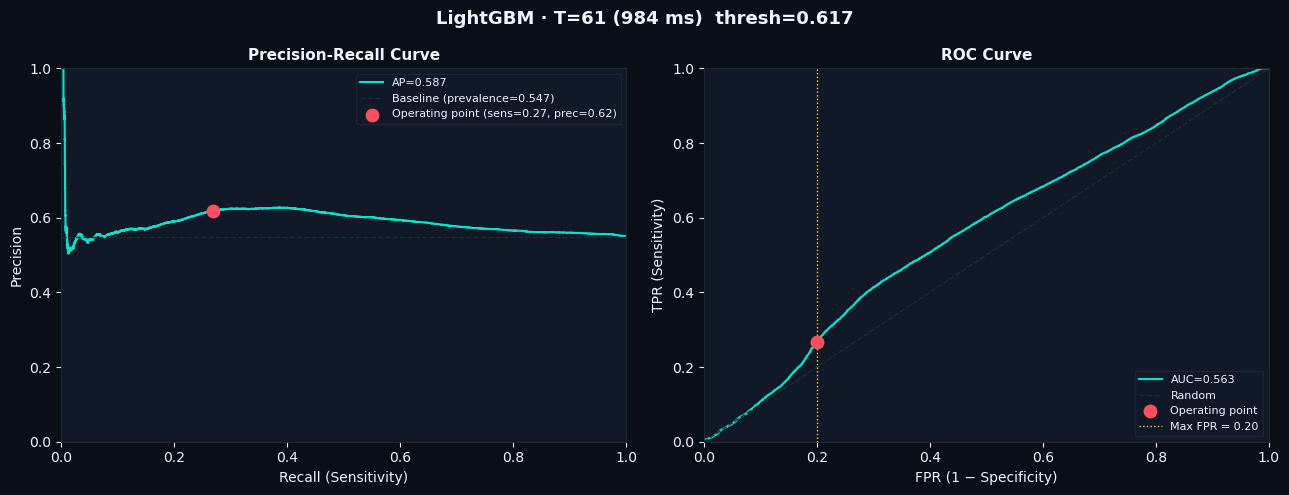

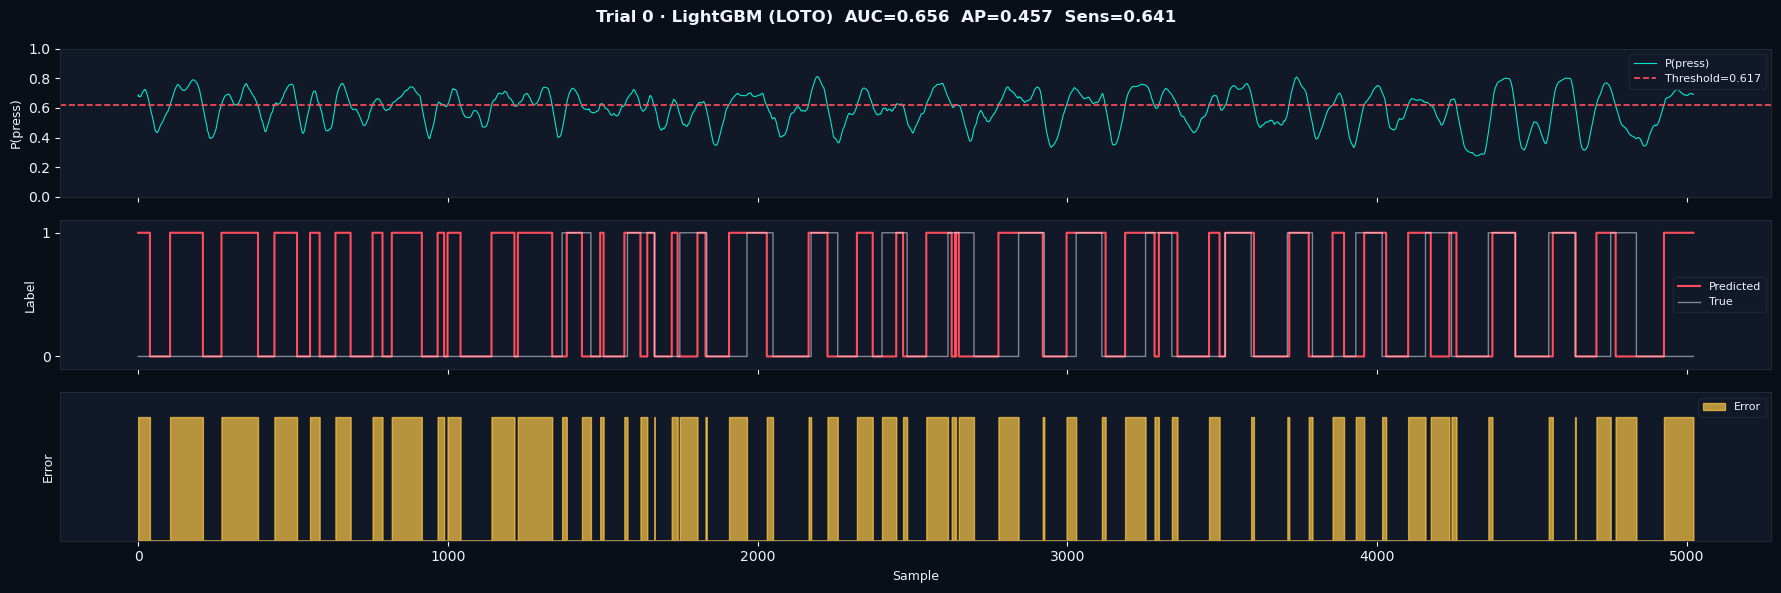

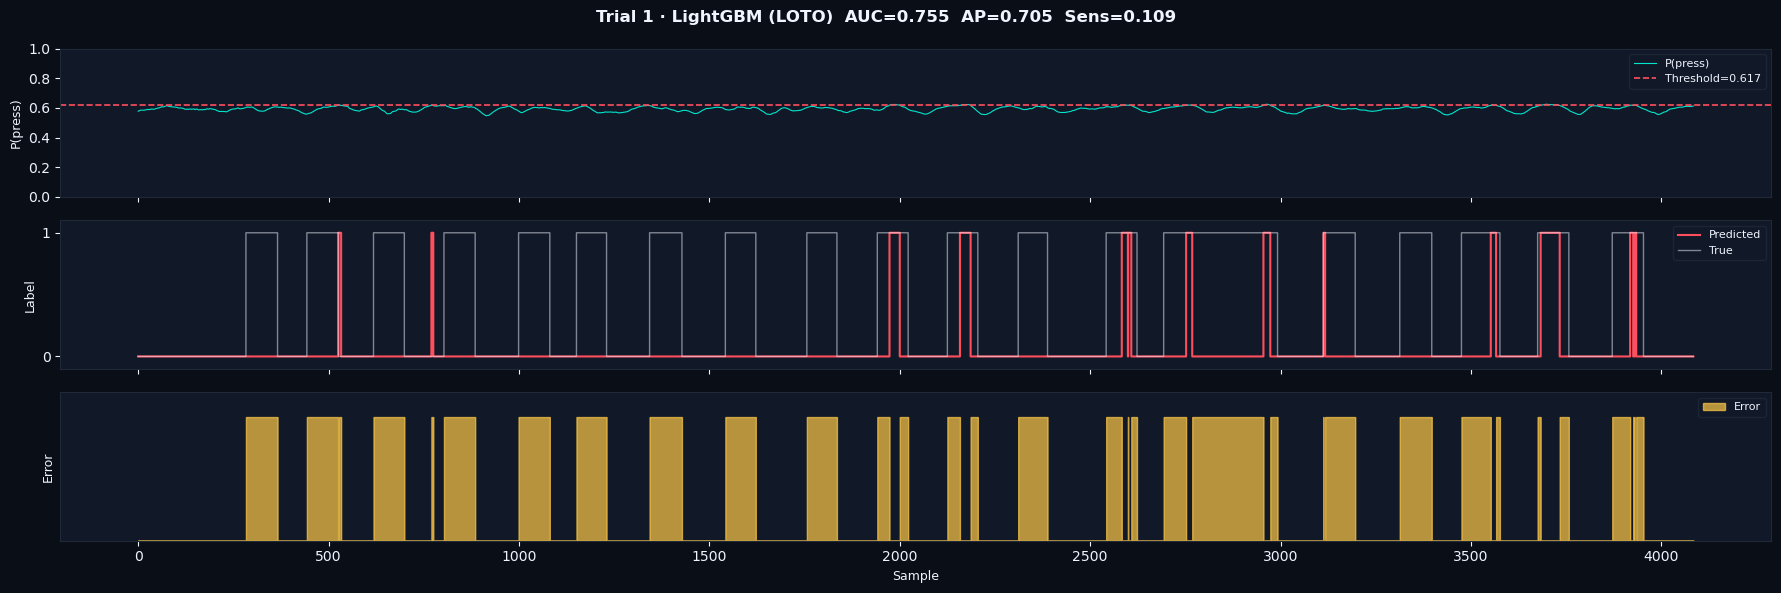

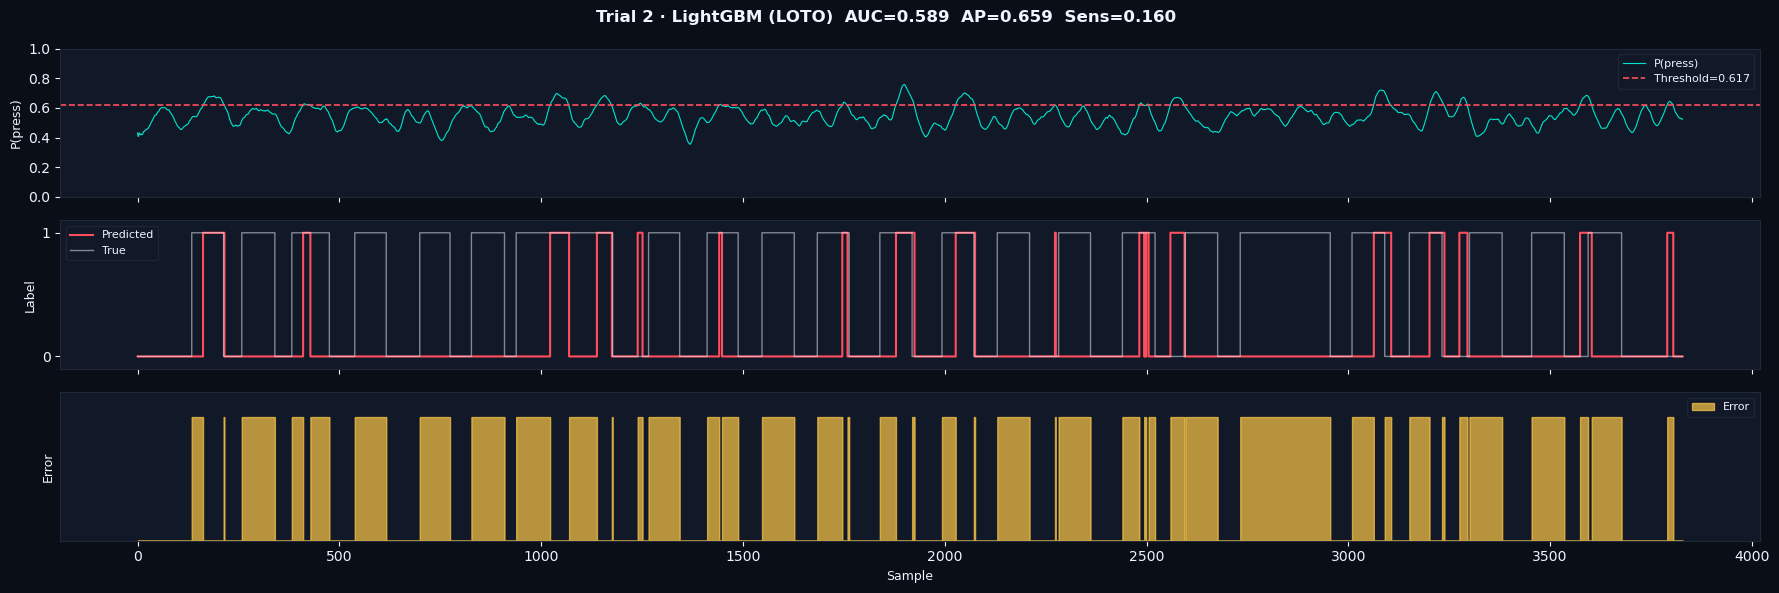

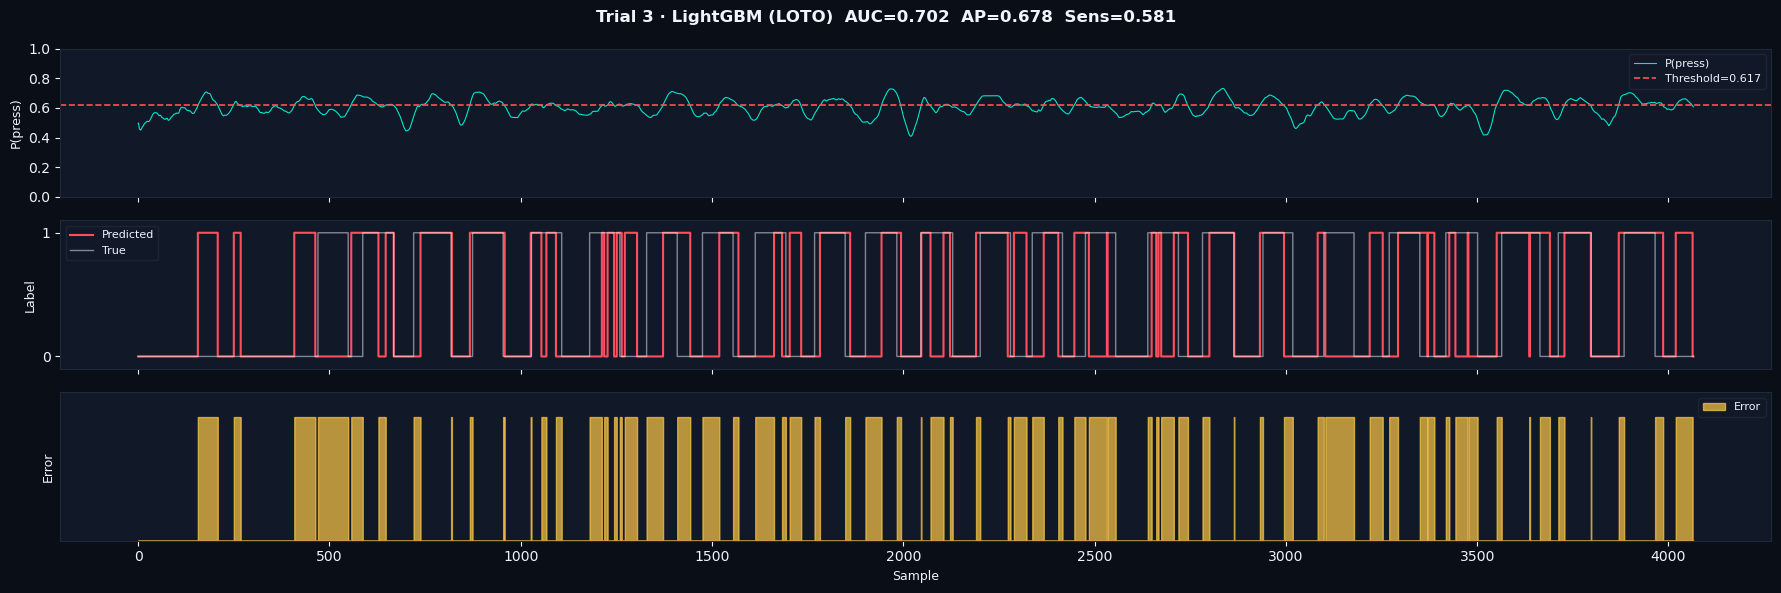

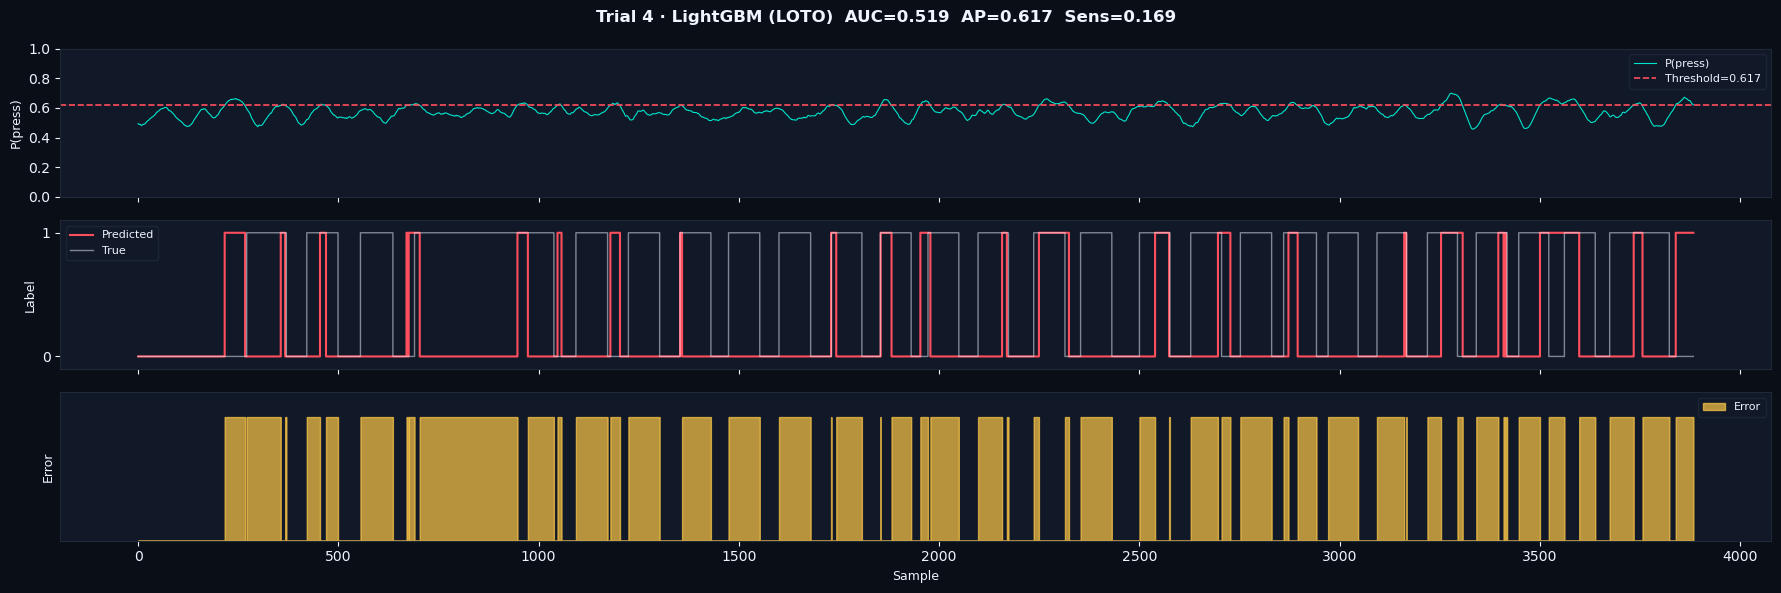

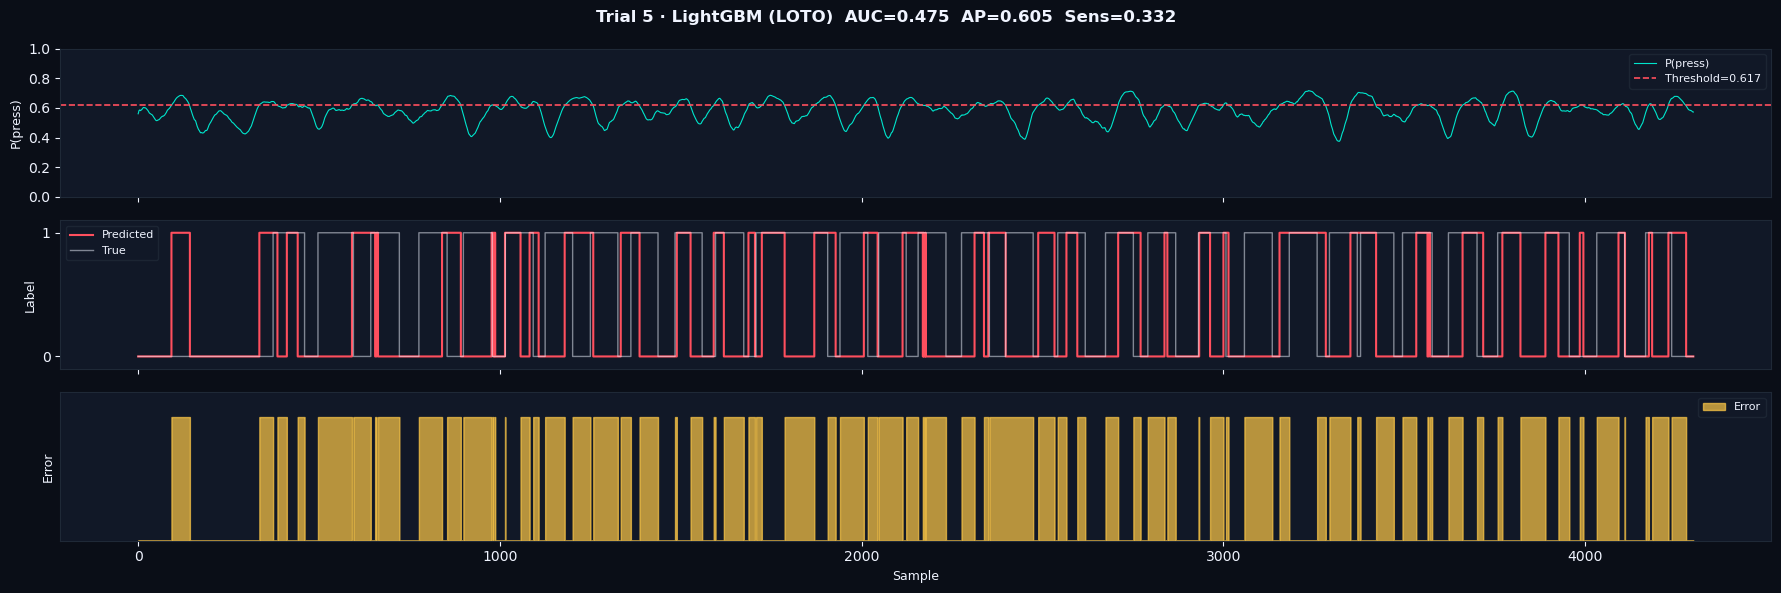

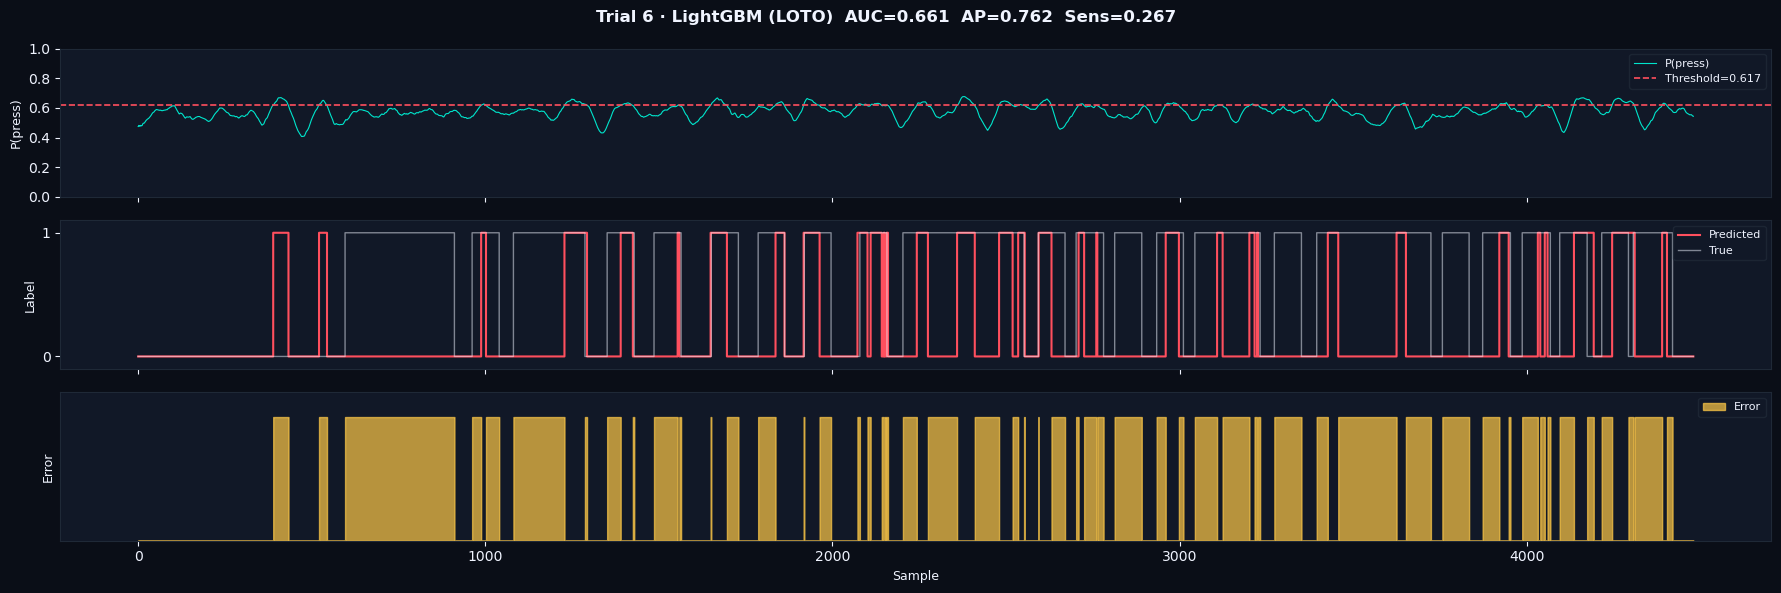

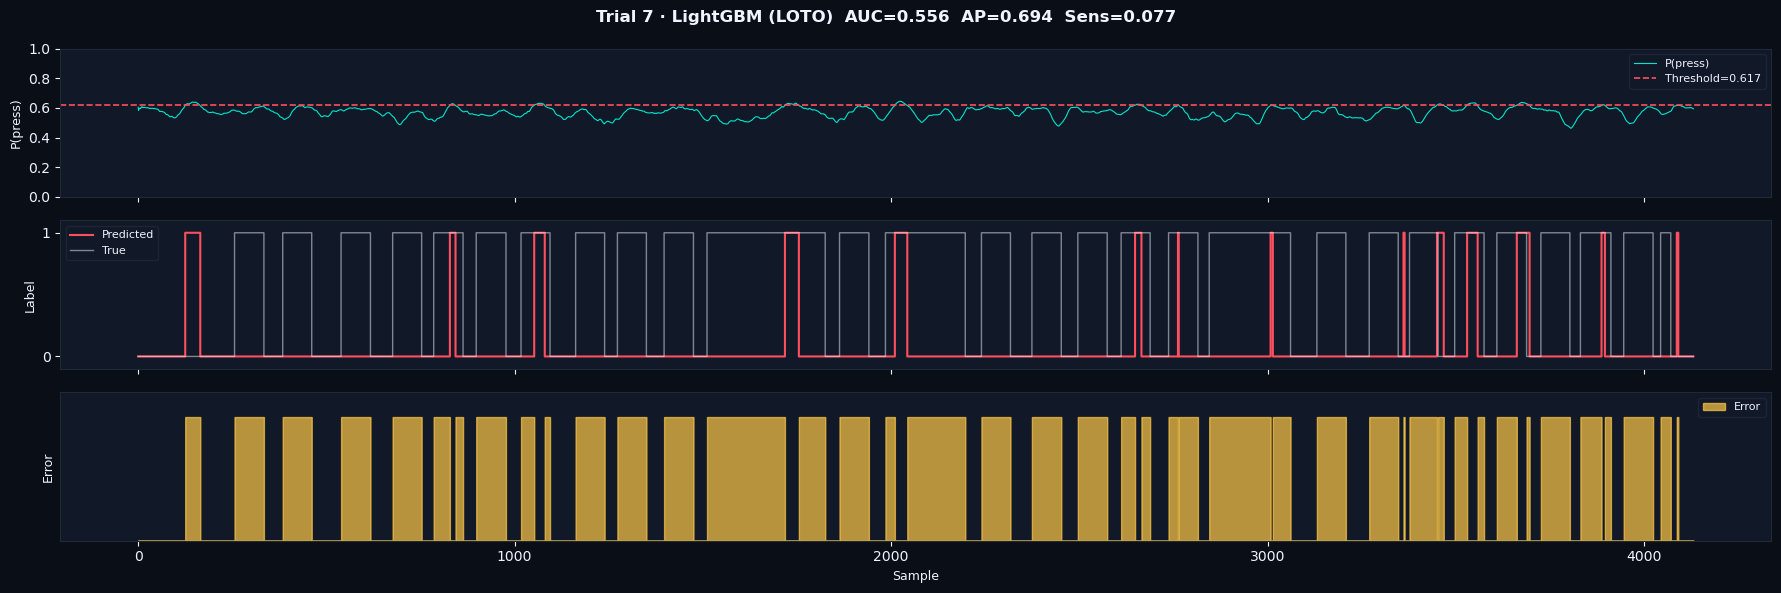

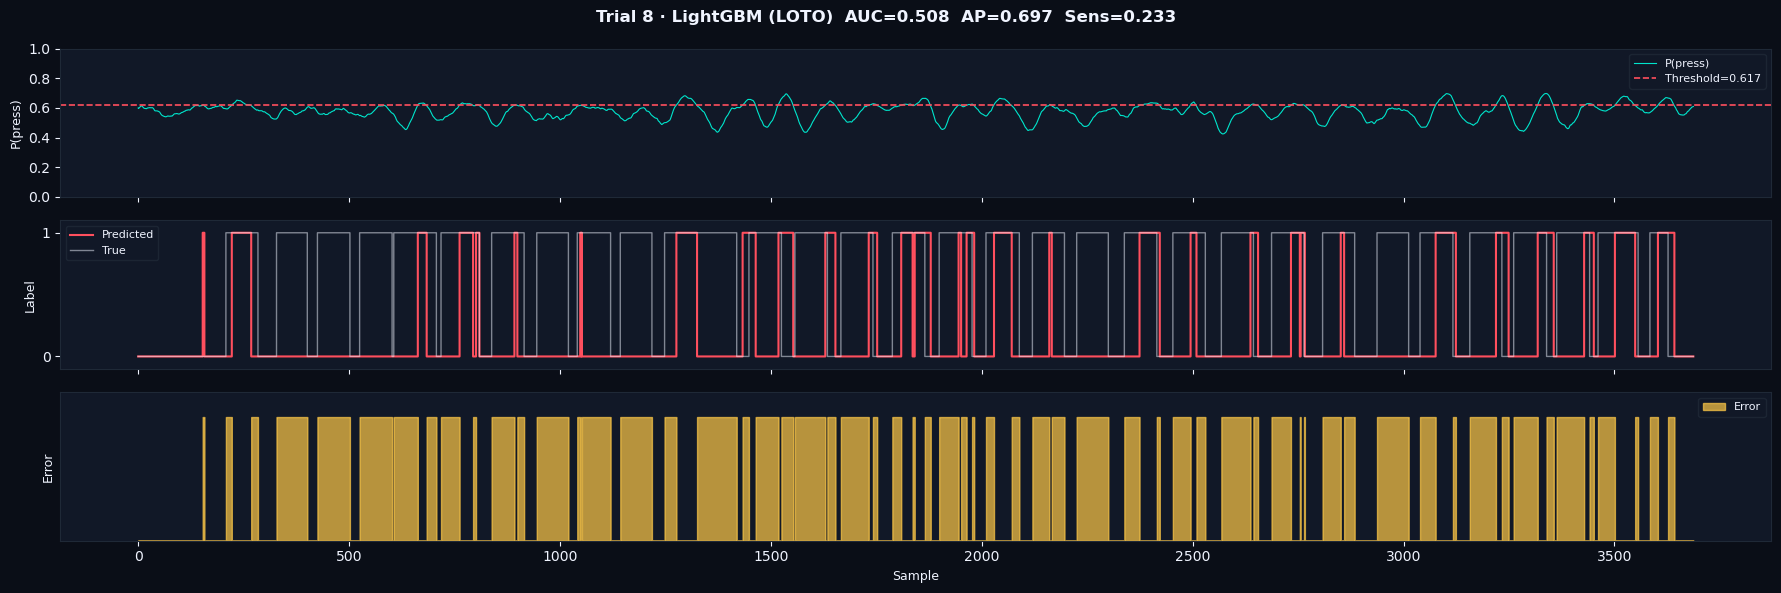

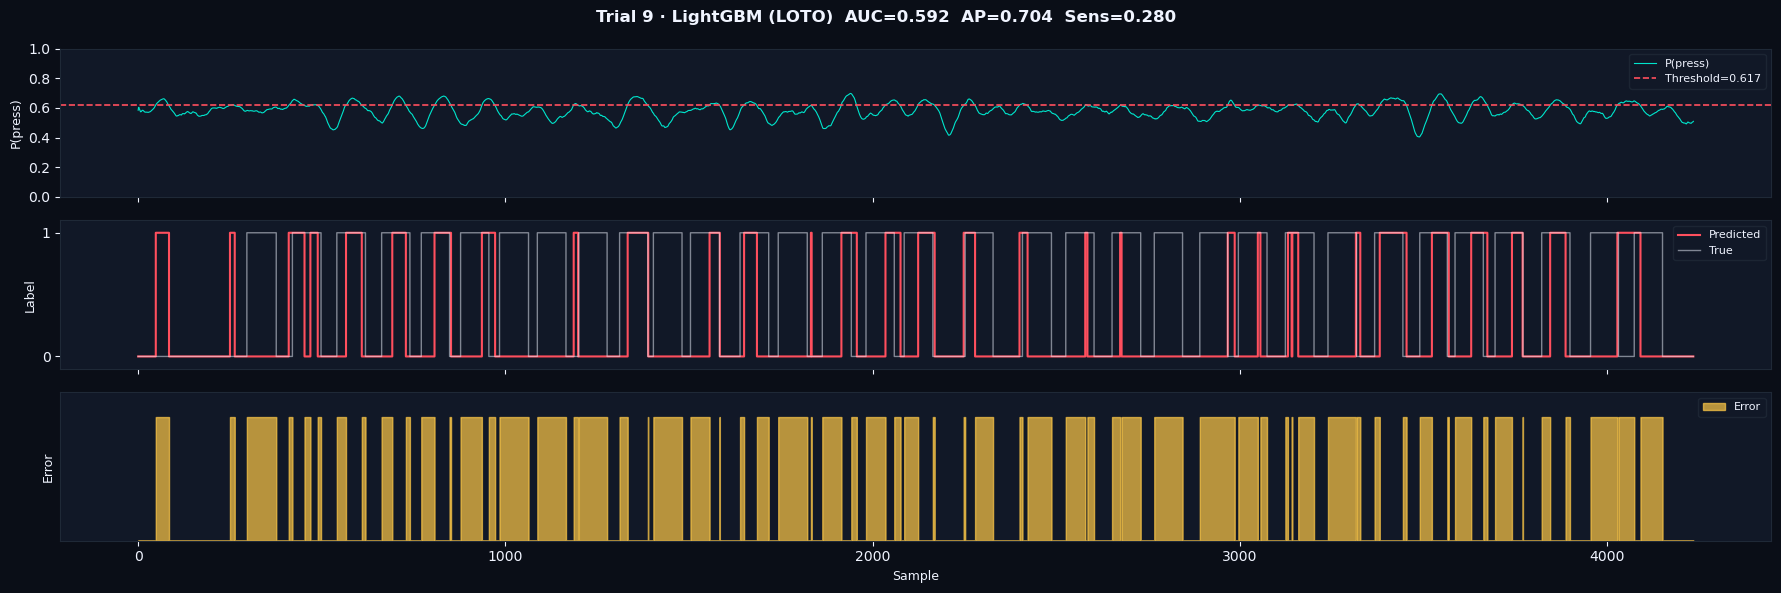

In [11]:
for test_trial in ALL_TRIALS:
    te_mask = tid_pool == test_trial
    probs_t = all_probs_smooth[te_mask]
    preds_t = preds_smooth[te_mask]
    y_t = y_pool[te_mask]
    auc_t = roc_auc_score(y_t, probs_t)
    ap_t = average_precision_score(y_t, probs_t)
    sens_t = (preds_t[y_t == 1] == 1).mean() if y_t.sum() > 0 else 0.0

    fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
    t_axis = np.arange(len(probs_t))

    ax = axes[0]
    ax.set_facecolor(CARD)
    ax.plot(t_axis, probs_t, color=TEAL, lw=0.8, label="P(press)")
    ax.axhline(thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={thresh:.3f}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(press)", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[1]
    ax.set_facecolor(CARD)
    ax.plot(
        t_axis, preds_t, drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted"
    )
    ax.plot(
        t_axis,
        y_t,
        drawstyle="steps-post",
        color=WHITE,
        lw=1.0,
        alpha=0.5,
        label="True",
    )
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_ylabel("Label", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[2]
    ax.set_facecolor(CARD)
    errors = (preds_t != y_t).astype(float)
    ax.fill_between(t_axis, errors, color=GOLD, alpha=0.7, step="post", label="Error")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    ax.set_ylabel("Error", color=WHITE, fontsize=9)
    ax.set_xlabel("Sample", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    fig.suptitle(
        f"Trial {test_trial} · LightGBM (LOTO)  "
        f"AUC={auc_t:.3f}  AP={ap_t:.3f}  Sens={sens_t:.3f}",
        color=WHITE,
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 12 · Feature Importance Heatmap

Importance reshaped to `(C, T)` — reveals which channels and temporal lags the model relies on.  
Pre-movement motor channels (contralateral to the pressing hand) should dominate.

In [12]:
imp_matrix = importances.reshape(N_CHANNELS, T)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

im = ax.imshow(imp_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Importance")
ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(EEG_COLS, color=WHITE, fontsize=9)
ax.set_xlabel("Lag (samples before target,  0 = most recent)", color=WHITE, fontsize=10)
ax.set_title(
    "Feature Importance — Channel × Temporal Lag",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)

best_ch, best_lag = np.unravel_index(imp_matrix.argmax(), imp_matrix.shape)
ax.add_patch(
    plt.Rectangle(
        (best_lag - 0.5, best_ch - 0.5), 1, 1, fill=False, edgecolor=CORAL, lw=2.5
    )
)
ax.text(
    best_lag,
    best_ch - 0.6,
    f"peak: {EEG_COLS[best_ch]} lag={best_lag}",
    color=CORAL,
    fontsize=8,
    ha="center",
)
plt.tight_layout()

## 13 · Per-Channel Total Importance

In [13]:
ch_importance = imp_matrix.sum(axis=1)
order = np.argsort(ch_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

bar_colours = [GOLD if i == 0 else TEAL for i in range(N_CHANNELS)]
ax.bar(
    range(N_CHANNELS),
    ch_importance[order],
    color=bar_colours,
    alpha=0.9,
    edgecolor=EDGE,
)
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(
    [EEG_COLS[i] for i in order], color=WHITE, fontsize=9, rotation=30, ha="right"
)
ax.set_ylabel("Total Importance (sum over lags)", color=WHITE, fontsize=10)
ax.set_title("Per-Channel Importance", color=WHITE, fontsize=13, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)
plt.tight_layout()

## 14 · Save Model

In [14]:
SAVE_PATH = f"../data/subject{SUBJECT}/model_lgbm"
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(best_lgb, f"{SAVE_PATH}/eeg_lgb_model.joblib")
joblib.dump(calibrated_lgb, f"{SAVE_PATH}/eeg_lgb_calibrated.joblib")

params_to_save = {
    "T": int(T),
    "n_estimators": int(n_estimators),
    "num_leaves": int(num_leaves),
    "learning_rate": float(learning_rate),
    "min_child_samples": int(min_child_samples),
    "subsample": float(subsample),
    "colsample_bytree": float(colsample_bytree),
    "class_weight": class_weight,
    "best_loto_auc": float(np.mean(final_aucs)),
    "best_loto_ap": float(np.mean(final_aps)),
    "best_thresh": float(thresh),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "smooth_window": int(SMOOTH_WINDOW),
    "min_specificity": float(MIN_SPECIFICITY),
    "n_channels": int(N_CHANNELS),
    "channel_names": EEG_COLS,
    "fs": int(FS_EFF),
    "per_window_norm": True,
    "n_trials_trained": len(ALL_TRIALS),
}
with open(f"{SAVE_PATH}/eeg_lgb_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)

print("Saved:")
print(f"  {SAVE_PATH}/eeg_lgb_model.joblib")
print(f"  {SAVE_PATH}/eeg_lgb_calibrated.joblib")
print(f"  {SAVE_PATH}/eeg_lgb_params.json")
print(
    f"\nKey metrics saved: AUC={np.mean(final_aucs):.4f}  AP={np.mean(final_aps):.4f}  sens={sensitivity:.4f}  spec={specificity:.4f}"
)


Saved:
  ../data/subject9/model_lgbm/eeg_lgb_model.joblib
  ../data/subject9/model_lgbm/eeg_lgb_calibrated.joblib
  ../data/subject9/model_lgbm/eeg_lgb_params.json

Key metrics saved: AUC=0.6182  AP=0.6559  sens=0.2684  spec=0.8000
